In [4]:
# ==========================================================
# AI & ML Task-3
# Model Validation, Overfitting Control & Hyperparameter Tuning
# ==========================================================

# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [5]:
# ==========================================================
# Load Dataset
# ==========================================================

housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data,
     housing.target.rename("HousePrice")],
    axis=1
)

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [6]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]


In [7]:
# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [9]:
# ==========================================================
# Models
# ==========================================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=100
    )
}

results = []

print("="*60)
print("BASE MODEL PERFORMANCE")
print("="*60)

for name, model in models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    cv = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    cv_rmse = -cv.mean()

    results.append([
        name,
        train_rmse,
        test_rmse,
        cv_rmse,
        train_r2,
        test_r2
    ])

    print(f"\n{name}")
    print("Train RMSE :", round(train_rmse,3))
    print("Test RMSE  :", round(test_rmse,3))
    print("CV RMSE    :", round(cv_rmse,3))
    print("Train R2   :", round(train_r2,3))
    print("Test R2    :", round(test_r2,3))

BASE MODEL PERFORMANCE

Linear Regression
Train RMSE : 0.72
Test RMSE  : 0.746
CV RMSE    : 0.746
Train R2   : 0.613
Test R2    : 0.576

Ridge Regression
Train RMSE : 0.72
Test RMSE  : 0.746
CV RMSE    : 0.746
Train R2   : 0.613
Test R2    : 0.576

Decision Tree
Train RMSE : 0.0
Test RMSE  : 0.703
CV RMSE    : 0.896
Train R2   : 1.0
Test R2    : 0.623

Random Forest
Train RMSE : 0.188
Test RMSE  : 0.505
CV RMSE    : 0.651
Train R2   : 0.974
Test R2    : 0.805


In [11]:
# ==========================================================
# Overfitting Analysis
# ==========================================================

print("\n")
print("="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

for row in results:

    model = row[0]
    train = row[1]
    test = row[2]

    print(model)

    if train < test * 0.75:
        print("Model is likely Overfitting")

    elif abs(train-test) < 0.1:
        print("Good Generalization")

    else:
        print("Slight Overfitting")

    print()



OVERFITTING ANALYSIS
Linear Regression
Good Generalization

Ridge Regression
Good Generalization

Decision Tree
Model is likely Overfitting

Random Forest
Model is likely Overfitting



In [12]:
# ==========================================================
# Hyperparameter Tuning
# Decision Tree
# ==========================================================

dt_param = {

    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]

}

grid_dt = GridSearchCV(

    DecisionTreeRegressor(random_state=42),

    param_grid=dt_param,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)

grid_dt.fit(X_train,y_train)

best_dt = grid_dt.best_estimator_

print("\nBest Decision Tree Parameters")
print(grid_dt.best_params_)


Best Decision Tree Parameters
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [13]:
# ==========================================================
# Hyperparameter Tuning
# Random Forest
# ==========================================================

rf_param = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid_rf = GridSearchCV(

    RandomForestRegressor(random_state=42),

    param_grid=rf_param,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)

grid_rf.fit(X_train,y_train)

best_rf = grid_rf.best_estimator_

print("\nBest Random Forest Parameters")
print(grid_rf.best_params_)


Best Random Forest Parameters
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [14]:
# ==========================================================
# Evaluate Tuned Models
# ==========================================================

print("\n")
print("="*60)
print("TUNED MODEL PERFORMANCE")
print("="*60)

final_models = {

    "Decision Tree Tuned":best_dt,
    "Random Forest Tuned":best_rf

}

comparison=[]

for name,model in final_models.items():

    pred=model.predict(X_test)

    rmse=np.sqrt(mean_squared_error(y_test,pred))

    r2=r2_score(y_test,pred)

    cv=cross_val_score(

        model,

        X_scaled,

        y,

        cv=5,

        scoring="neg_root_mean_squared_error"

    )

    comparison.append([

        name,

        rmse,

        -cv.mean(),

        r2

    ])

    print(name)

    print("RMSE :",round(rmse,3))

    print("CV RMSE :",round(-cv.mean(),3))

    print("R2 :",round(r2,3))

    print()



TUNED MODEL PERFORMANCE
Decision Tree Tuned
RMSE : 0.639
CV RMSE : 0.769
R2 : 0.688

Random Forest Tuned
RMSE : 0.504
CV RMSE : 0.649
R2 : 0.806



In [15]:
# ==========================================================
# Model Comparison Table
# ==========================================================

comparison_df=pd.DataFrame(

comparison,

columns=[

"Model",

"Test RMSE",

"Cross Validation RMSE",

"R2 Score"

]

)

print("\n")
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(comparison_df)



FINAL MODEL COMPARISON
                 Model  Test RMSE  Cross Validation RMSE  R2 Score
0  Decision Tree Tuned   0.638936               0.768669  0.688464
1  Random Forest Tuned   0.503949               0.649022  0.806194


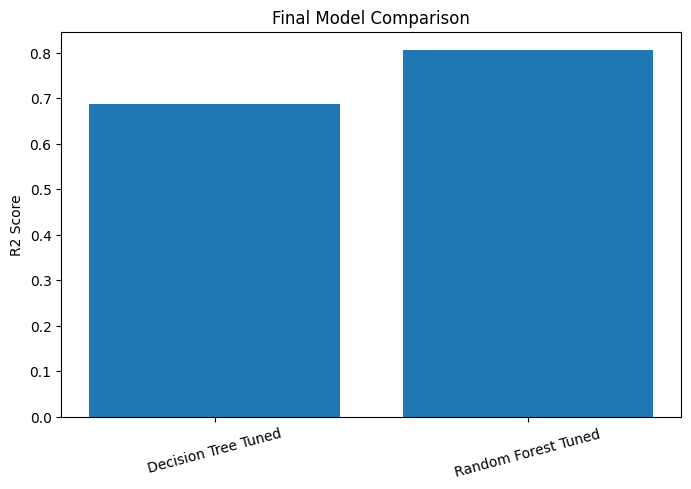

In [16]:
# ==========================================================
# Plot Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"],
        comparison_df["R2 Score"])

plt.title("Final Model Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=15)

plt.show()

In [17]:
# ==========================================================
# Save Best Model
# ==========================================================

import joblib

joblib.dump(best_rf,"best_house_price_model.pkl")

print("\nBest model saved successfully.")


Best model saved successfully.
